# Explore here

In [2]:
# Your code here
import requests
from zipfile import ZipFile
from io import BytesIO
import os
import shutil

In [3]:
#  Download the dataset
url = "https://storage.googleapis.com/datascience-materials/dogs-vs-cats.zip"
response = requests.get(url)

In [4]:
#  Extract to "dogs-vs-cats"
with ZipFile(BytesIO(response.content)) as zip_file:
    zip_file.extractall("dogs-vs-cats")

In [6]:
#  Correct the nested structure
# Original images are in: dogs-vs-cats/dogs-vs-cats/train/
source_train = "dogs-vs-cats/dogs-vs-cats/train"
dest_train = "dogs-vs-cats/train"

os.makedirs(dest_train, exist_ok=True)

In [7]:
# Move all images into a single folder first
for filename in os.listdir(source_train):
    src_path = os.path.join(source_train, filename)
    dst_path = os.path.join(dest_train, filename)
    shutil.move(src_path, dst_path)

In [8]:
#  Create cats/ and dogs/ folders for TensorFlow
cats_folder = os.path.join(dest_train, "cats")
dogs_folder = os.path.join(dest_train, "dogs")
os.makedirs(cats_folder, exist_ok=True)
os.makedirs(dogs_folder, exist_ok=True)

for filename in os.listdir(dest_train):
    file_path = os.path.join(dest_train, filename)
    if filename.startswith("cat"):
        shutil.move(file_path, cats_folder)
    elif filename.startswith("dog"):
        shutil.move(file_path, dogs_folder)

In [12]:
#  Load the dataset
import tensorflow as tf
train_dataset = tf.keras.utils.image_dataset_from_directory(
    dest_train,
    labels="inferred",
    label_mode="binary",
    batch_size=32,
    image_size=(150,150),
    shuffle=True
)

print("Dataset loaded successfully!")

Found 25000 files belonging to 2 classes.
Dataset loaded successfully!


In [ ]:
import random
import shutil
import os
#creating test folder importing images into them
os.makedirs("dogs-vs-cats/test/cats", exist_ok=True)
os.makedirs("dogs-vs-cats/test/dogs", exist_ok=True)

train_cats = os.listdir("dogs-vs-cats/train/cats")
train_dogs = os.listdir("dogs-vs-cats/train/dogs")

for f in random.sample(train_cats, 500):
    shutil.move(f"dogs-vs-cats/train/cats/{f}","dogs-vs-cats/test/cats/{f}")
for f in random.sample(train_dogs, 500):
    shutil.move(f"dogs-vs-cats/train/dogs/{f}","dogs-vs-cats/test/dogs/{f}")

In [16]:
datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_data = datagen.flow_from_directory(
    "dogs-vs-cats/train",
    target_size=(150,150),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

val_data = datagen.flow_from_directory(
    "dogs-vs-cats/train",
    target_size=(150,150),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)

Found 19200 images belonging to 2 classes.
Found 4800 images belonging to 2 classes.


In [19]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras import Input, Model
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Rescaling

In [20]:
inputs = keras.Input(shape=(150, 150, 3)) #rgb images
x = layers.Conv2D(64, 3, activation='relu')(inputs)
x = layers.MaxPooling2D()(x)
x = layers.Conv2D(128, 3, activation='relu')(x)
x = layers.MaxPooling2D()(x)
x = layers.Conv2D(256, 3, activation='relu')(x)
x = layers.GlobalAveragePooling2D()(x)
outputs = layers.Dense(1, activation='sigmoid')(x)
model = keras.Model(inputs, outputs)

In [21]:
model.compile(optimizer='adam',
              loss ='binary_crossentropy',
              metrics=['accuracy'])

In [22]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 148, 148, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 74, 74, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 72, 72, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 36, 36, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 34, 34, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 371,073 (1.42 MB)

 Trainable params: 371,073 (1.42 MB)

 Non-trainable params: 0 (0.00 B)

In [23]:
model.fit(train_data,
          validation_data=val_data,
          epochs=5,
          verbose=2,
          steps_per_epoch=100,
          validation_steps=50)

Epoch 1/5


2026-01-15 17:59:53.239983: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 179437568 exceeds 10% of free system memory.
2026-01-15 17:59:53.514999: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 44859392 exceeds 10% of free system memory.
2026-01-15 17:59:53.557059: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 84934656 exceeds 10% of free system memory.
2026-01-15 17:59:53.899732: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 37879808 exceeds 10% of free system memory.
2026-01-15 17:59:54.164886: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 37879808 exceeds 10% of free system memory.


100/100 - 268s - 3s/step - accuracy: 0.5288 - loss: 0.6900 - val_accuracy: 0.5962 - val_loss: 0.6706
Epoch 2/5
100/100 - 256s - 3s/step - accuracy: 0.5831 - loss: 0.6679 - val_accuracy: 0.6087 - val_loss: 0.6541
Epoch 3/5
100/100 - 262s - 3s/step - accuracy: 0.6044 - loss: 0.6554 - val_accuracy: 0.6062 - val_loss: 0.6550
Epoch 4/5
100/100 - 262s - 3s/step - accuracy: 0.5981 - loss: 0.6524 - val_accuracy: 0.5612 - val_loss: 0.6625
Epoch 5/5
100/100 - 262s - 3s/step - accuracy: 0.6294 - loss: 0.6403 - val_accuracy: 0.6862 - val_loss: 0.6011


In [24]:
loss, accuracy = model.evaluate(train_data, verbose=2)
print(f"Training validation Accuracy: {accuracy}")

600/600 - 397s - 661ms/step - accuracy: 0.6697 - loss: 0.6085
Training validation Accuracy: 0.6697396039962769


In [25]:
loss, accuracy = model.evaluate(val_data, verbose=2)
print(f"Validation Accuracy: {accuracy}")

150/150 - 97s - 649ms/step - accuracy: 0.6750 - loss: 0.6045
Validation Accuracy: 0.675000011920929


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


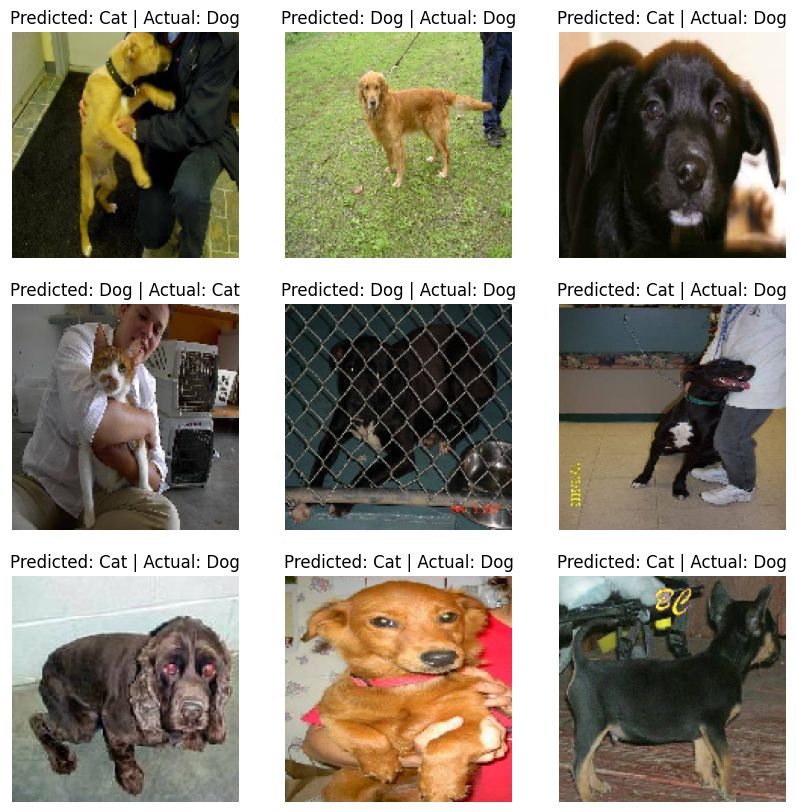

In [30]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,10))
for i in range(9):  
    ax = plt.subplot(3,3,i+1)
    img, label = val_data[i]
    prediction = model.predict(tf.expand_dims(img[0], axis=0))
    plt.imshow(img[0])
    plt.title(f"Predicted: {'Dog' if prediction[0][0]>0.5 else 'Cat'} | Actual: {'Dog' if label[0]==1 else 'Cat'}")
    plt.axis("off")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step


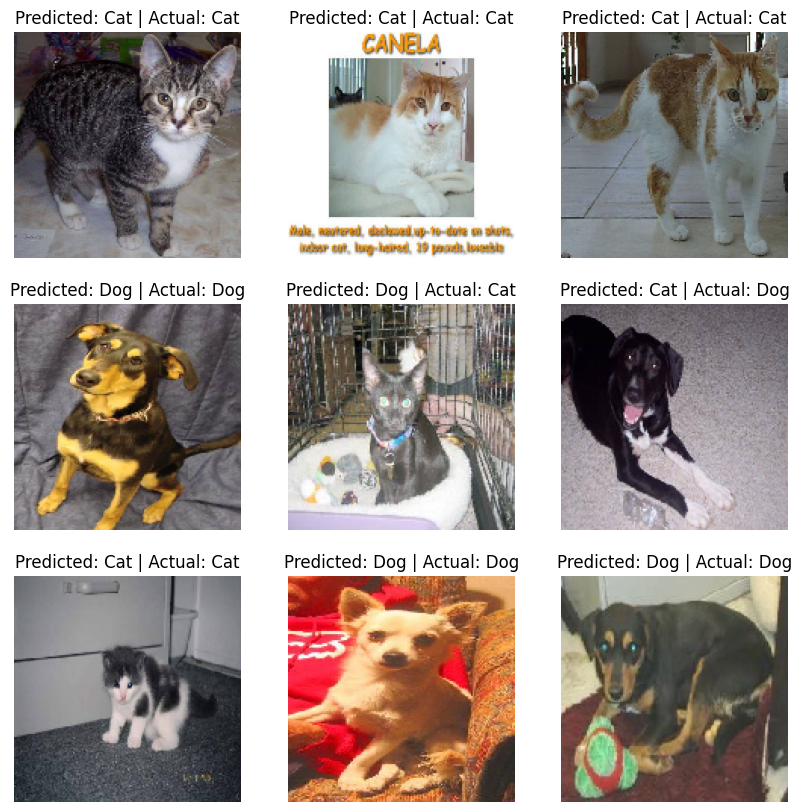

In [32]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,10))
for i in range(9):  
    ax = plt.subplot(3,3,i+1)
    img, label = train_data[i]
    prediction = model.predict(tf.expand_dims(img[0], axis=0))
    plt.imshow(img[0])
    plt.title(f"Predicted: {'Dog' if prediction[0][0]>0.5 else 'Cat'} | Actual: {'Dog' if label[0]==1 else 'Cat'}")
    plt.axis("off")